This notebook contains scripts that calculate everything needed for Fig 4

Files needed:
 - files with drivers (from country, state and city folders, e.g.'country/Delta_SouthKorea_drivers_full_Ranks_RoundedHLA.csv'), 
 - files with all EVs frequencies (from country, state and city folders, e.g. 'country/Delta_country_SouthKorea_Ranks_RoundedHLA.csv').

In [3]:
import numpy as np
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as pltcol
from scipy import stats
import math
from scipy.stats import mannwhitneyu
import glob
from scipy.stats import ttest_ind
import statsmodels.stats.multitest as multi
import cmasher as cmr
#from adjustText import adjust_text

In [3]:
#for fig. 4a
ds_types = ['country', 'state', 'city']
countries = ['UnitedKingdom','Switzerland', 'Netherlands', 'Croatia', 'Poland', 'Romania', 'Norway', 'Sweden', 'Spain', 'Russia','Italy', 'Slovakia', 'Germany',  'Ireland','Austria', 'Portugal','CzechRepublic',  'France', 'Greece','Turkey',  'UnitedArabEmirates', 'SouthKorea', 'Japan', 'Malaysia','Thailand','SriLanka', 'Nigeria', 'Brazil','Colombia', 'Argentina','Chile','Mexico']
thr_list = []
d_tables = dict()
om_tables = dict()
ev_more1mut = 0
for ds_type in ds_types:
    files = glob.glob(ds_type+'/*'+ds_type+'*_Ranks_RoundedHLA.csv')
    names = set([i.split('_')[-3] for i in files])
    for name in names:
        if (name not in d_tables.keys())&(name in countries):
            d_tables[name] = pd.read_csv(ds_type+ '/Delta_' +ds_type +'_'+name+ '_Ranks_RoundedHLA.csv', dtype={'Allele frequency': str}, index_col = False).replace(r'no_freq{1,}', 0, regex=True)
            d_tables[name]['Country'] = name
            d_tables[name]['Allele frequency'] = d_tables[name]['Allele frequency'].astype('float')
            om_tables[name] = pd.read_csv(ds_type+ '/Omicron_' +ds_type +'_'+name+ '_Ranks_RoundedHLA.csv', dtype={'Allele frequency': str}, index_col = False).replace(r'no_freq{1,}', 0, regex=True)
            om_tables[name]['Country'] = name 
            om_tables[name]['Allele frequency'] = om_tables[name]['Allele frequency'].astype('float')            
d_all = pd.concat(list(d_tables.values()))
d_all['Country'] = [''.join([' '+ s if s.isupper()  else s for s in i]).lstrip() for i in d_all['Country']]
d_all['Country'] = d_all['Country'].replace('United Arab Emirates', 'UAE').replace('United Kingdom', 'UK')
d_all_t = d_all[(d_all['mutations'] != 'wt')&(d_all['month'] == 'total')&(~d_all['Allele Name'].str.startswith('HLA-C'))]
om_all = pd.concat(list(om_tables.values()))
om_all['Country'] = [''.join([' '+ s if s.isupper()  else s for s in i]).lstrip() for i in om_all['Country']]
om_all['Country'] = om_all['Country'].replace('United Arab Emirates', 'UAE').replace('United Kingdom', 'UK')
om_all_t = om_all[(om_all['mutations'] != 'wt')&(om_all['month'] == 'total')&(~om_all['Allele Name'].str.startswith('HLA-C'))]
print('d_all_t', d_all_t.shape)
print('om_all_t', om_all_t.shape)

d_tables_drivers = {}
om_tables_drivers = {}
d_tables_drivers_contr = {}
om_tables_drivers_contr = {}

for ds_type in ds_types:
    files = glob.glob(ds_type+'/*'+ds_type+'*_Ranks_RoundedHLA.csv')
    names = set([i.split('_')[-3] for i in files])
    print(names)
    for name in names:
        if (name not in d_tables_drivers.keys())&(name in countries):
            d_tables_drivers[name] = pd.read_csv(ds_type+'/Delta_' + name + '_drivers_full_Ranks_RoundedHLA.csv', dtype={'Allele frequency': str}, index_col = False)
            d_tables_drivers[name]['Country'] = name
            d_tables_drivers[name] = d_tables_drivers[name][~d_tables_drivers[name]['Allele Name'].str.startswith('HLA-C')]
            
            om_tables_drivers[name] = pd.read_csv(ds_type+'/Omicron_' +name + '_drivers_full_Ranks_RoundedHLA.csv', dtype={'Allele frequency': str}, index_col = False)
            om_tables_drivers[name] = om_tables_drivers[name][~om_tables_drivers[name]['Allele Name'].str.startswith('HLA-C')]
            om_tables_drivers[name]['Country'] = name
            d_tables_drivers_contr[name] = pd.read_csv(ds_type+'/Delta_' +name + '_driversCONTRsTRONG15_full_Ranks_RoundedHLA_breakFiltered.csv', dtype={'Allele frequency': str}, index_col = False)
            d_tables_drivers_contr[name] = d_tables_drivers_contr[name][~d_tables_drivers_contr[name]['Allele Name'].str.startswith('HLA-C')]
            d_tables_drivers_contr[name]['Country'] = name
            om_tables_drivers_contr[name] = pd.read_csv(ds_type+'/Omicron_' +name + '_driversCONTRsTRONG15_full_Ranks_RoundedHLA_breakFiltered.csv', dtype={'Allele frequency': str}, index_col = False)        
            om_tables_drivers_contr[name] = om_tables_drivers_contr[name][~om_tables_drivers_contr[name]['Allele Name'].str.startswith('HLA-C')]
            om_tables_drivers_contr[name]['Country'] = name
            
om_all_drivers = pd.concat(om_tables_drivers.values())
om_all_drivers['Country'] = [''.join([' '+ s if s.isupper()  else s for s in i]).lstrip() for i in om_all_drivers['Country']]
om_all_drivers['Country'] = om_all_drivers['Country'].replace('United Arab Emirates', 'UAE').replace('United Kingdom', 'UK')
om_all_drivers['EL_mark'] = 'Lost binding'
d_all_drivers = pd.concat(d_tables_drivers.values())
d_all_drivers['Country'] = [''.join([' '+ s if s.isupper()  else s for s in i]).lstrip() for i in d_all_drivers['Country']]
d_all_drivers['Country'] = d_all_drivers['Country'].replace('United Arab Emirates', 'UAE').replace('United Kingdom', 'UK')
d_all_drivers['EL_mark'] = 'Lost binding'
om_all_drivers_c = pd.concat(om_tables_drivers_contr.values())
om_all_drivers_c['Country'] = [''.join([' '+ s if s.isupper()  else s for s in i]).lstrip() for i in om_all_drivers_c['Country']]
om_all_drivers_c['Country'] = om_all_drivers_c['Country'].replace('United Arab Emirates', 'UAE').replace('United Kingdom', 'UK')
om_all_drivers_c['EL_mark'] = 'Increased binding'
d_all_drivers_c = pd.concat(d_tables_drivers_contr.values())
d_all_drivers_c['Country'] = [''.join([' '+ s if s.isupper()  else s for s in i]).lstrip() for i in d_all_drivers_c['Country']]
d_all_drivers_c['Country'] = d_all_drivers_c['Country'].replace('United Arab Emirates', 'UAE').replace('United Kingdom', 'UK')
d_all_drivers_c['EL_mark'] = 'Increased binding'

print('d_all_drivers_c', d_all_drivers_c.shape)
print('om_all_drivers_c', om_all_drivers_c.shape)

d_all_t (422398, 16)
om_all_t (570976, 16)
{'Germany', 'Croatia', 'Romania', 'Slovakia', 'Thailand', 'SouthKorea', 'Portugal', 'Poland', 'Nigeria', 'France', 'Turkey', 'UnitedArabEmirates', 'Norway', 'Malaysia', 'Italy', 'Sweden', 'Ireland', 'CzechRepublic', 'Austria', 'Greece', 'Japan'}
{'Spain', 'Brazil', 'Mexico', 'UnitedKingdom', 'Russia'}
{'Switzerland', 'Italy', 'Russia', 'Sweden', 'SriLanka', 'Brazil', 'Argentina', 'Chile', 'Mexico', 'Portugal', 'UnitedKingdom', 'Colombia', 'France', 'Netherlands'}
d_all_drivers_c (21044, 27)
om_all_drivers_c (23912, 27)


(30, 9)
(31, 9)
HLA-A01 0.7650293255131965 3.415092240928987e-07
(31, 10)
10    Nigeria
Name: Country, dtype: object
HLA-A01 0.7650293255131965 3.415092240928987e-07
(31, 10)
10    Nigeria
Name: Country, dtype: object


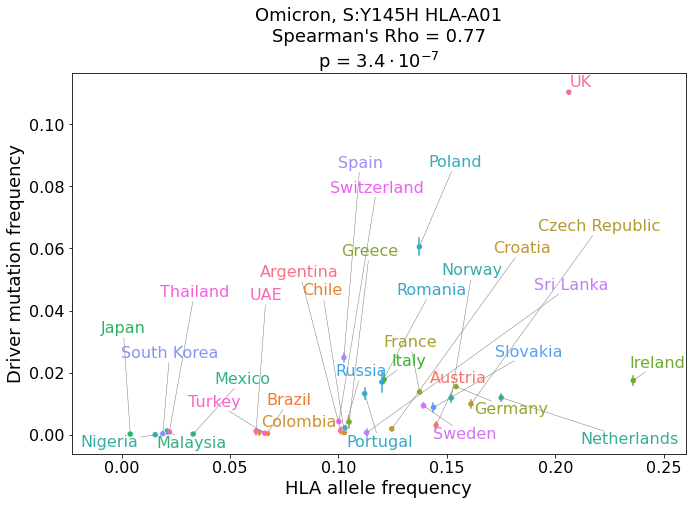

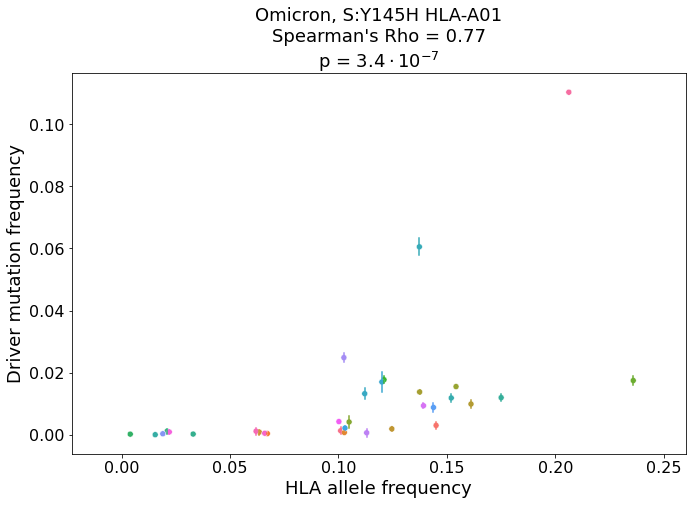

(29, 9)
(30, 9)
HLA-A03 0.64967919340055 5.7284001669382354e-05
(30, 10)
10      Nigeria
26    Sri Lanka
Name: Country, dtype: object
HLA-A03 0.64967919340055 5.7284001669382354e-05
(30, 10)
10      Nigeria
26    Sri Lanka
Name: Country, dtype: object


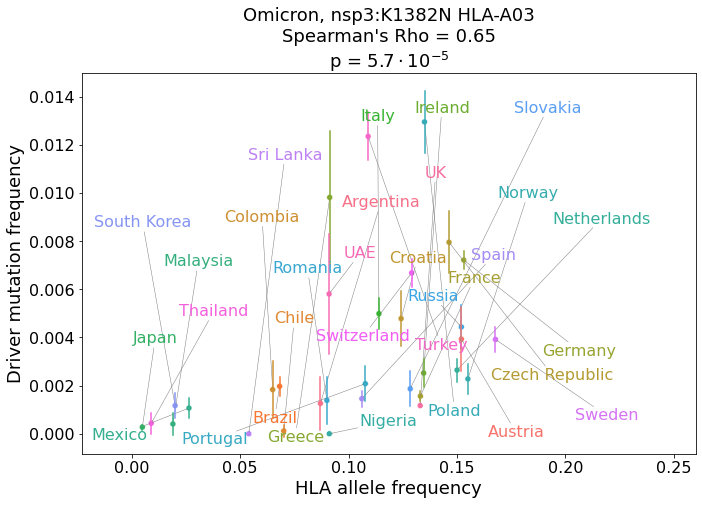

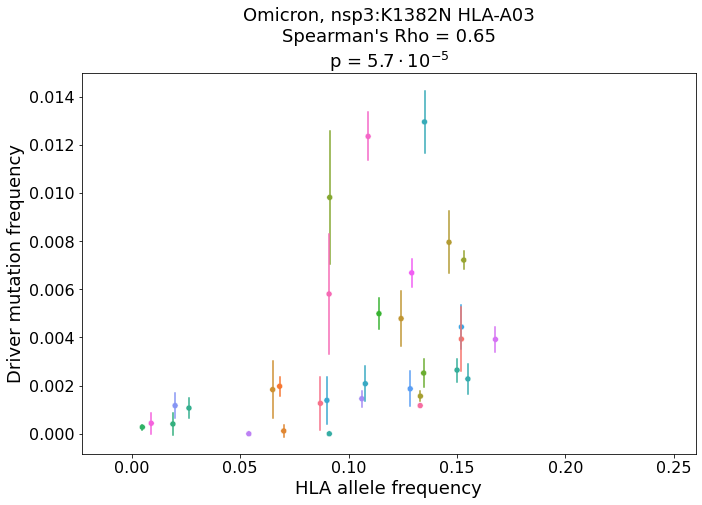

In [29]:
#for fig. 4a
from adjustText import adjust_text
from math import floor, log10
def sci_notation(num, decimal_digits=1, precision=None, exponent=None):
    if exponent is None:
        exponent = int(floor(log10(abs(num))))
    coeff = round(num / float(10**exponent), decimal_digits)
    if precision is None:
        precision = decimal_digits

    return r"${0:.{2}f}\cdot10^{{{1:d}}}$".format(coeff, exponent, precision)


d_all_t = d_all_t[d_all_t['Allele frequency']>0]
d_top_drivers = d_all_drivers.groupby(['prot_name', 'peptide', 'Allele Name', 'driver_mut_total', 'muts_with_driver_total', 'driver_fraction_total']).agg({'Country':'size', 'Allele frequency_total':'first', 'fraction_max':'first', 'fraction_total':'first'}).reset_index()
d_top_drivers = d_top_drivers[(d_top_drivers['muts_with_driver_total'] >1)&
                              (d_top_drivers['driver_fraction_total']>0.9)&
    (~d_top_drivers['Allele Name'].str.startswith('HLA-C'))].drop_duplicates(['prot_name', 'peptide', 'Allele Name', 'driver_mut_total'])
d_top_drivers['prot_mut'] = d_top_drivers['prot_name'] +'_'+ d_top_drivers['driver_mut_total']

all_countries_info = d_all_t.drop_duplicates(['Allele Name','Country'])[['Allele Name','Allele frequency', 'Country']].drop_duplicates()

top_drivers = d_top_drivers.copy()
mut_table = top_drivers.drop_duplicates(['driver_mut_total', 'Allele Name', 'peptide'])
table_all = d_all_t.copy()
table_all['Allele frequency'] = [i if j == 'Lost binding' else 0 for i, j in zip(table_all['Allele frequency'], table_all['EL_mark'])]


mut_table = mut_table[(mut_table['driver_mut_total'] == 'K1382N')|(mut_table['driver_mut_total'] == 'Y145H')]

for hla in set(mut_table['Allele Name']):
    table_with_muts = mut_table.copy()
    muts = list(set(table_with_muts[(table_with_muts['Allele Name'] == hla)]['driver_mut_total'].values))
    for mut in muts:
        for pept in mut_table[(mut_table['Allele Name'] == hla)&(mut_table['driver_mut_total'] == mut)]['peptide'].values: 
            tab = table_all[(table_all['peptide'] == pept)&(table_all['Allele Name']== hla)&
                (table_all['mutations'].str.contains(mut))&(table_all['month'] == 'total')].drop_duplicates()
            tab_freq = tab.groupby(['prot_name', 'peptide', 'Allele Name', 'Country']).agg({
                    'fraction':'sum', 'Allele frequency':'first', 'mutations':('_').join, 'total_sequences':'first'}).reset_index().drop_duplicates()
            #print(tab_freq.shape)
            tab_freq['driver_mut_for_pict'] = mut
            print(tab_freq.shape)
            if (tab_freq.shape[0]>=25):
                tab_freq = pd.merge(all_countries_info[all_countries_info['Allele Name'] == hla], tab_freq, on = ['Country', 'Allele Name'], how = 'left').fillna(0)
                tab_freq['driver_mut_for_pict'] = [i if i !=0 else mut for i in tab_freq['driver_mut_for_pict']]
                tab_freq = tab_freq.rename(columns = {'Allele frequency_x':'Allele frequency'}).drop_duplicates().sort_values('Country')
                #tab_freq = tab_freq[tab_freq['fraction']>0]
                rho, pval = stats.spearmanr(tab_freq['Allele frequency'],tab_freq['fraction'])                
                if pval < 0.05:
                    fig, ax = plt.subplots(figsize = (11,7))
                    colors = dict(zip(tab_freq['Country'], sns.color_palette("husl", tab_freq.shape[0])))

                    print(hla,  rho, pval)
                    g = sns.scatterplot(data=tab_freq, x='Allele frequency', y='fraction', hue='Country', ax=ax, palette = sns.color_palette("husl", tab_freq.shape[0]), 
                                               hue_order = tab_freq['Country'], legend=False)
                    texts = []
                    prev_al = 10
                    prev_frac = 10
                    for index, row in tab_freq.sort_values(['fraction', 'Allele frequency'], ascending = False).iterrows():
                        al_dif = abs(prev_al - row['Allele frequency'])
                        frac_dif = abs(prev_frac - row['fraction'])
                        
                        if True:
                            texts.append(plt.text(row['Allele frequency'], row['fraction'], row['Country'], color = colors[row['Country']], fontsize = 16))
                        prev_al = row['Allele frequency']
                        prev_frac = row['fraction']
                        #print(row['Allele frequency'], row['fraction'], row['Country'], colors[row['Country']])
                        if row['fraction']!=0:
                            ax.plot([row['Allele frequency'], row['Allele frequency']], [row['fraction'] - 1.96*(row['fraction']*(1-row['fraction'])/row['total_sequences'])**0.5, 
                                    row['fraction'] + 1.96*(row['fraction']*(1-row['fraction'])/row['total_sequences'])**0.5], 
                                    color = colors[row['Country']])  
                    ax.set_xlim(-0.023, 0.26)
                    tab = tab.replace('Spike', 'S')
                    ax.set_title(strain + ', ' + tab['prot_name'].values[0] + ':'+mut + ' ' + hla + '\n' + 'Spearman\'s '+ 'Rho = ' + f'{rho:.02f}'  + '\n' + 'p = ' + sci_notation(float(f'{pval:.01e}')),
                                 fontsize = 18)
                    
                    nlabels = len(ax.texts)
                    adjust_text(texts, only_move={'texts':'xy'}, force_text = (0.4,4),arrowprops=dict(arrowstyle="->", color='gray', lw=0.5))
                    for new, old in zip(ax.texts[nlabels:], ax.texts):
                        new.arrow_patch.set_color(old.get_color())

                    print(tab_freq[tab_freq['mutations']!=0].shape)
                    print(tab_freq[tab_freq['mutations']==0]['Country'])
                    #plt.savefig('Geogr_corrs/'+hla.split('-')[1]+'_'+strain +'_AllCountries_' +mut +'_RoundedHLA.svg', bbox_inches = "tight")
                    ax.set_xlabel('HLA allele frequency'  , fontsize = 18)
                    ax.set_ylabel('Driver mutation frequency'  , fontsize = 18)
                    ax.tick_params(axis = 'both', labelsize=16)
                    plt.savefig('Fig4/'+strain+'_' +mut +'_withText.jpg', dpi=300, bbox_inches='tight')
                    
                    fig, ax = plt.subplots(figsize = (11,7))
                    colors = dict(zip(tab_freq['Country'], sns.color_palette("husl", tab_freq.shape[0])))

                    print(hla,  rho, pval)
                    g = sns.scatterplot(data=tab_freq, x='Allele frequency', y='fraction', hue='Country', ax=ax, palette = sns.color_palette("husl", tab_freq.shape[0]), 
                                               hue_order = tab_freq['Country'], legend=False)
                    texts = []
                    prev_al = 10
                    prev_frac = 10
                    for index, row in tab_freq.sort_values(['fraction', 'Allele frequency'], ascending = False).iterrows():
                        if row['fraction']!=0:
                            ax.plot([row['Allele frequency'], row['Allele frequency']], [row['fraction'] - 1.96*(row['fraction']*(1-row['fraction'])/row['total_sequences'])**0.5, 
                                    row['fraction'] + 1.96*(row['fraction']*(1-row['fraction'])/row['total_sequences'])**0.5], 
                                    color = colors[row['Country']])  
                    ax.set_xlim(-0.023, 0.26)
                    tab = tab.replace('Spike', 'S')
                    ax.set_title(strain + ', ' + tab['prot_name'].values[0] + ':'+mut + ' ' + hla + '\n' + 'Spearman\'s '+ 'Rho = ' + f'{rho:.02f}'  + '\n' + 'p = ' + sci_notation(float(f'{pval:.01e}')),
                                 fontsize = 18)

                    print(tab_freq[tab_freq['mutations']!=0].shape)
                    print(tab_freq[tab_freq['mutations']==0]['Country'])
                    #plt.savefig('Geogr_corrs/'+hla.split('-')[1]+'_'+strain +'_AllCountries_' +mut +'_RoundedHLA.svg', bbox_inches = "tight")
                    ax.set_xlabel('HLA allele frequency'  , fontsize = 18)
                    ax.set_ylabel('Driver mutation frequency'  , fontsize = 18)
                    ax.tick_params(axis = 'both', labelsize=16)
                    plt.savefig('Fig4/'+strain+'_' +mut +'_withoutText.jpg', dpi=300, bbox_inches='tight')
                    plt.show()

In [ ]:
import numpy as np
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as pltcol
from scipy import stats
import math
from scipy.stats import mannwhitneyu
import glob
from scipy.stats import ttest_ind
import statsmodels.stats.multitest as multi
import cmasher as cmr
from scipy.stats import rankdata, t
import os
from joblib import Parallel, delayed

# -----------------------------
# HELPERS (parallel workers)
# -----------------------------
def _spearman_xy(df: pd.DataFrame):
    x = df["Allele frequency"].to_numpy()
    y = df["fraction"].to_numpy()
    return stats.spearmanr(x, y)

def _process_group_nonsyn(key, grp, *, strain, el_mark, countries_ok, country_of_orig_map, country_of_orig_len_map):
    """
    key: (prot, pept, hla, mut)
    grp: slice of tab_freq_all for that key
    returns dict with tab + stats + bookkeeping
    """
    prot, pept, hla, mut = key

    tab = grp.drop(columns=["total_sequences"], errors="ignore")

    # your existing logic
    tab = fill_zeros_for_hla(strain, hla, tab, prot=prot, pept=pept, mut=mut)
    tab = tab[tab["Country"].isin(countries_ok)].drop_duplicates().sort_values("Country")

    tab["driver_mut_for_pict"] = mut

    rho, pval = _spearman_xy(tab)
    if isinstance(pval, float) and math.isnan(pval):
        # keep behavior: print problematic table
        print("NaN pval for:", key)
        print(tab)

    tab["EL_mark"] = el_mark
    tab["strain"] = strain

    country_of_orig = country_of_orig_map.get(mut, [])
    tab["country_of_orig"] = "_".join(country_of_orig)
    tab["country_of_orig_length"] = country_of_orig_len_map.get(mut, 0)

    nonzero_c = tab.loc[tab["fraction"] != 0].shape[0]

    return {"key": key,
        "tab": tab,
        "rho": rho,
        "pval": pval,
        "nonzero_c": nonzero_c}

def _process_group_syn(key, grp, *, strain, el_mark, countries_ok, country_of_orig_map, country_of_orig_len_map):
    """
    key: (pept, hla, mut)
    """
    pept, hla, mut, prot = key

    tab = grp.drop(columns=["mut", "total_sequences"], errors="ignore")

    # BUGFIX: in your original syn block, prot wasn't defined.
    tab = fill_zeros_for_hla(strain, hla, tab, prot=prot, pept=pept, mut=mut)

    tab = tab[tab["Country"].isin(countries_ok)].drop_duplicates().sort_values("Country")

    rho, pval = _spearman_xy(tab)

    tab["EL_mark"] = el_mark
    tab["strain"] = strain

    country_of_orig = country_of_orig_map.get(mut, [])
    tab["country_of_orig"] = "_".join(country_of_orig)
    tab["country_of_orig_length"] = country_of_orig_len_map.get(mut, 0)

    nonzero_c = tab.loc[tab["fraction"] != 0].shape[0]

    return {
        "key": key,
        "tab": tab,
        "rho": rho,
        "pval": pval,
        "nonzero_c": nonzero_c,}

def _safe_dirname(s: str) -> str:
    return "".join(ch if ch.isalnum() or ch in ("_", "-", ".") else "_" for ch in s)

def make_full_info(df):
    countries = df["Country"].unique()
    alleles   = df["Allele Name"].unique()

    full_index = pd.MultiIndex.from_product(
        [countries, alleles],
        names=["Country", "Allele Name"])

    # map Country -> total_sequences (assumes it's constant within Country)
    ts_map = df.drop_duplicates("Country").set_index("Country")["total_sequences"]

    df_filled = (
        df.set_index(["Country", "Allele Name"])
          .reindex(full_index)
          .reset_index())

    df_filled["Allele frequency"] = df_filled["Allele frequency"].fillna(0)

    # fill total_sequences for the new rows
    df_filled["total_sequences"] = df_filled["Country"].map(ts_map)

    return df_filled

def explode_mutations(df: pd.DataFrame) -> pd.DataFrame:
    """
    Explode comma-separated mutations into one row per mutation token.
    Keeps original 'mutations' column, adds 'mut' column.
    """
    out = df.copy()
    out["mut"] = (out["mutations"].astype(str)
                  .str.replace(r"\s+", "", regex=True)
                  .str.split(","))
    out = out.explode("mut", ignore_index=True)
    out["mut"] = out["mut"].astype(str).str.strip()
    out = out[out["mut"].ne("")]
    return out



def build_country_origin_maps(strain_driver_table: pd.DataFrame, countries_ok=None) -> tuple[dict, dict]:
    """
    Build exactly:
      country_of_orig_map[mut] = list(set(Country)) for rows where driver_mut_total == mut
    If countries_ok is provided, restrict origins to those countries only.
    """
    src = strain_driver_table.loc[
        ~strain_driver_table["Allele Name"].astype(str).str.startswith("HLA-C"),
        ["driver_mut_total", "Country"]
    ].drop_duplicates().copy()

    # Optional restriction to countries_ok (if you want it)
    if countries_ok is not None:
        src = src[src["Country"].isin(countries_ok)].copy()

    # Normalize whitespace (prevents "V155I" vs "V155I ")
    src["driver_mut_total"] = src["driver_mut_total"].astype(str).str.strip()
    src["Country"] = src["Country"].astype(str).str.strip()

    country_of_orig_map = (src.groupby("driver_mut_total")["Country"]
                           .apply(lambda s: list(set(s)))  # same semantics as your original code
                           .to_dict())
    country_of_orig_len_map = {k: len(v) for k, v in country_of_orig_map.items()}
    return country_of_orig_map, country_of_orig_len_map

def build_country_origin_maps_synon(strain_driver_table: pd.DataFrame, countries_ok=None) -> tuple[dict, dict]:
    """
    Build exactly:
      country_of_orig_map[mut] = list(set(Country)) for rows where driver_mut_total == mut
    """
    src = strain_driver_table.loc[
        ~strain_driver_table["Allele Name"].astype(str).str.startswith("HLA-C"),
        ["mutations_total", "Country"]].drop_duplicates().copy()


    # Normalize whitespace (prevents "V155I" vs "V155I ")
    #src["mutations"] = src["mutations"].astype(str).str.strip()
    #src["Country"] = src["Country"].astype(str).str.strip()

    country_of_orig_map = (src.groupby("mutations_total")["Country"]
                           .apply(lambda s: list(set(s)))  # same semantics as your original code
                           .to_dict())
    country_of_orig_len_map = {k: len(v) for k, v in country_of_orig_map.items()}
    return country_of_orig_map, country_of_orig_len_map


def fill_zeros_for_hla(strain: str, hla: str, tab_freq: pd.DataFrame,
                       prot: str, pept: str, mut: str) -> pd.DataFrame:
    """
    Right-join against base countries for this HLA to add zero rows,
    and fill group identifiers on those rows (so no NaNs in prot/pept/mut).
    """
    try:
        base_hla = base_idx[strain].loc[(hla, slice(None)), :].reset_index()  # Allele Name, Country, Allele frequency
    except KeyError:
        # If we have no base info for this HLA at all, return as-is
        tab_freq = tab_freq.copy()
        tab_freq["prot_name"] = prot
        tab_freq["peptide"] = pept
        tab_freq["mut"] = mut
        tab_freq["Allele Name"] = hla
        return tab_freq

    merged = base_hla.merge(tab_freq, on=["Allele Name", "Country"], how="left")

    # Fill identifiers for added rows
    merged["prot_name"] = prot
    merged["peptide"] = pept
    merged["mut"] = mut
    merged["Allele Name"] = hla

    # Fill numeric columns
    merged["fraction"] = pd.to_numeric(merged.get("fraction"), errors="coerce").fillna(0.0)
    #merged["total_sequences"] = pd.to_numeric(merged.get("total_sequences"), errors="coerce").fillna(0)

    # Keep base allele frequency column (if merge created x/y)
    if "Allele frequency_x" in merged.columns and "Allele frequency_y" in merged.columns:
        merged["Allele frequency"] = merged["Allele frequency_x"].fillna(merged["Allele frequency_y"])
        merged = merged.drop(columns=["Allele frequency_x", "Allele frequency_y"])
    merged["Allele frequency"] = pd.to_numeric(merged.get("Allele frequency"), errors="coerce").fillna(0)
    return merged

import sys
from contextlib import contextmanager

class Tee:
    def __init__(self, *streams):
        self.streams = streams
    def write(self, data):
        for s in self.streams:
            s.write(data)
    def flush(self):
        for s in self.streams:
            if hasattr(s, "flush"):
                s.flush()

@contextmanager
def tee_output(log_path, mode="w", buffering=1):
    """
    Tee stdout+stderr to BOTH the notebook output and a log file.
    Always restores stdout/stderr even if interrupted or error happens.
    """
    old_out, old_err = sys.stdout, sys.stderr
    log = open(log_path, mode, buffering=buffering)
    try:
        sys.stdout = Tee(old_out, log)
        sys.stderr = Tee(old_err, log)
        yield
    finally:
        # restore notebook streams first
        sys.stdout, sys.stderr = old_out, old_err
        try:
            log.flush()
        finally:
            log.close()
def plot_correlation(table, n_iter, rho, pval, strain, pept, hla, mut, el_mark):
    tab_plot = pd.merge(countries_data[countries_data['strain'] == strain], table, on = ['Country'])
    tab_plot['SampleSize'] = np.log10(tab_plot['SampleSize'])                            
    tab_plot['fraction'] = tab_plot['fraction'].replace(0,1/10000000)

    fig, ax = plt.subplots(figsize = (6,5))
    ax.set_title(strain + ', ' + tab_plot[tab_plot['prot_name']!=0]['prot_name'].values[0] + ' '+pept + ' '+ hla + '\n'+ mut + '\n' + 'Spearman\'s '+ 'rho = ' + f'{rho:.02f}'  + '\n' + 'p-value = ' + f'{pval:.02e}',
                                             fontsize = 18)
    ax.set_xlabel(el_mark + '\nHLA allele frequency', fontsize = 18)
    ax.set_ylabel('Driver mutation frequency', fontsize = 18)
    ax.tick_params(axis = 'both', labelsize=16)
    ax.set_xlim(0, 0.025+tab_plot['Allele frequency'].max())
    ax.set_yscale('log')
    sns.scatterplot(data=tab_plot, x='Allele frequency', y='fraction', hue='Country', ax=ax, palette = sns.color_palette("husl", tab_plot.shape[0]), 
                                                               hue_order = countries, size = 'SampleSize',sizes=(20, 200),legend=True)
    ax.legend(bbox_to_anchor=(1.85, 1.15), ncols = 2)
    plt.savefig('geogr_shit/iteration'+ str(iteration_id) + '/' + strain + '_' +el_mark.split(' ')[0]+ '_'+ hla + '_' + pept+ '_' + mut+'.jpg', dpi=100, bbox_inches='tight', pad_inches=0.01)
    plt.close(fig)    


In [ ]:
ds_types = ['country', 'state', 'city']

countries = ['UnitedKingdom','Switzerland', 'Netherlands', 'Croatia', 'Poland', 'Romania', 'Norway', 'Sweden', 'Spain', 'Russia','Italy', 'Slovakia', 'Germany',  'Ireland','Austria', 'Portugal','CzechRepublic',  'France', 'Greece','Turkey',  'UnitedArabEmirates', 'SouthKorea', 'Japan', 'Malaysia','Thailand','SriLanka', 'Nigeria', 'Brazil','Colombia', 'Argentina','Chile','Mexico']
thr_list = []
d_tables = dict()
om_tables = dict()
ev_more1mut = 0
for ds_type in ds_types:
    files = glob.glob(ds_type+'/*'+ds_type+'*_Ranks_RoundedHLA.csv')
    names = set([i.split('_')[-3] for i in files])
    for name in names:
        if (name not in d_tables.keys())&(name in countries):
            d_tables[name] = pd.read_csv(ds_type+ '/Delta_' +ds_type +'_'+name+ '_Ranks_RoundedHLA.csv', dtype={'Allele frequency': str}, index_col = False).replace(r'no_freq{1,}', 0, regex=True)
            d_tables[name]['Country'] = name
            d_tables[name]['Allele frequency'] = d_tables[name]['Allele frequency'].astype('float')
            om_tables[name] = pd.read_csv(ds_type+ '/Omicron_' +ds_type +'_'+name+ '_Ranks_RoundedHLA.csv', dtype={'Allele frequency': str}, index_col = False).replace(r'no_freq{1,}', 0, regex=True)
            om_tables[name]['Country'] = name 
            om_tables[name]['Allele frequency'] = om_tables[name]['Allele frequency'].astype('float')            
d_all = pd.concat(list(d_tables.values()))
d_all_t = d_all[(d_all['mutations'] != 'wt')&(d_all['month'] == 'total')&(~d_all['Allele Name'].str.startswith('HLA-C'))]
om_all = pd.concat(list(om_tables.values()))
om_all_t = om_all[(om_all['mutations'] != 'wt')&(om_all['month'] == 'total')&(~om_all['Allele Name'].str.startswith('HLA-C'))]
print('d_all_t', d_all_t.shape)
print('om_all_t', om_all_t.shape)

d_all_t_syn = pd.read_csv('Delta_Synon_Ranks_RoundedHLA.csv', index_col = False).replace(r'no_freq{1,}', 0, regex=True)
d_all_t_syn = d_all_t_syn.rename(columns = {'country':'Country'})
d_all_t_syn = d_all_t_syn[(d_all_t_syn['Country']!='gisaid')&(d_all_t_syn['month'] == 'total')&(~d_all_t_syn['Allele Name'].str.startswith('HLA-C'))]
om_all_t_syn = pd.read_csv('Omicron_Synon_Ranks_RoundedHLA.csv', index_col = False).replace(r'no_freq{1,}', 0, regex=True)
om_all_t_syn = om_all_t_syn.rename(columns = {'country':'Country'})
om_all_t_syn = om_all_t_syn[(om_all_t_syn['Country']!='gisaid')&(om_all_t_syn['month'] == 'total')&(~om_all_t_syn['Allele Name'].str.startswith('HLA-C'))]

d_tables_drivers = {}
om_tables_drivers = {}
d_tables_drivers_contr = {}
om_tables_drivers_contr = {}
d_tables_drivers_syn = {}
om_tables_drivers_syn = {}
#ds_types = ['country', 'state', 'city']
#countries = ['UnitedKingdom','Switzerland', 'Netherlands', 'Croatia', 'Poland', 'Romania', 'Norway', 'Sweden', 'Spain', 'Russia','Italy', 'Slovakia', 'Germany',  'Ireland','Austria', 'Portugal','CzechRepublic',  'France', 'Greece','Turkey',  'UnitedArabEmirates', 'SouthKorea', 'Japan', 'Malaysia','Thailand','SriLanka', 'Nigeria', 'Brazil','Colombia', 'Argentina','Chile','Mexico']

for ds_type in ds_types:
    files = glob.glob(ds_type+'/*'+ds_type+'*_Ranks_RoundedHLA.csv')
    names = set([i.split('_')[-3] for i in files])
    print(names)
    for name in names:
        if (name not in d_tables_drivers.keys())&(name in countries):
            d_tables_drivers[name] = pd.read_csv(ds_type+'/Delta_' + name + '_drivers_full_Ranks_RoundedHLA.csv', dtype={'Allele frequency': str}, index_col = False)
            d_tables_drivers[name]['Country'] = name
            d_tables_drivers[name] = d_tables_drivers[name][~d_tables_drivers[name]['Allele Name'].str.startswith('HLA-C')]
            om_tables_drivers[name] = pd.read_csv(ds_type+'/Omicron_' +name + '_drivers_full_Ranks_RoundedHLA.csv', dtype={'Allele frequency': str}, index_col = False)
            om_tables_drivers[name] = om_tables_drivers[name][~om_tables_drivers[name]['Allele Name'].str.startswith('HLA-C')]
            om_tables_drivers[name]['Country'] = name
            
            d_tables_drivers_contr[name] = pd.read_csv(ds_type+'/Delta_' +name + '_driversCONTRsTRONG15_full_Ranks_RoundedHLA_breakFiltered.csv', dtype={'Allele frequency': str}, index_col = False)
            d_tables_drivers_contr[name] = d_tables_drivers_contr[name][~d_tables_drivers_contr[name]['Allele Name'].str.startswith('HLA-C')]
            d_tables_drivers_contr[name]['Country'] = name
            om_tables_drivers_contr[name] = pd.read_csv(ds_type+'/Omicron_' +name + '_driversCONTRsTRONG15_full_Ranks_RoundedHLA_breakFiltered.csv', dtype={'Allele frequency': str}, index_col = False)        
            om_tables_drivers_contr[name] = om_tables_drivers_contr[name][~om_tables_drivers_contr[name]['Allele Name'].str.startswith('HLA-C')]
            om_tables_drivers_contr[name]['Country'] = name

            d_tables_drivers_syn[name] = pd.read_csv(ds_type+'/Delta_' +name + '_drivers_full_Ranks_RoundedHLA_Synonymous.csv', dtype={'Allele frequency': str}, index_col = False)
            d_tables_drivers_syn[name] = d_tables_drivers_syn[name][~d_tables_drivers_syn[name]['Allele Name'].str.startswith('HLA-C')]
            d_tables_drivers_syn[name]['Country'] = name
            om_tables_drivers_syn[name] = pd.read_csv(ds_type+'/Omicron_' +name + '_drivers_full_Ranks_RoundedHLA_Synonymous.csv', dtype={'Allele frequency': str}, index_col = False)        
            om_tables_drivers_syn[name] = om_tables_drivers_syn[name][~om_tables_drivers_syn[name]['Allele Name'].str.startswith('HLA-C')]
            om_tables_drivers_syn[name]['Country'] = name

om_all_drivers = pd.concat(om_tables_drivers.values())
om_all_drivers['EL_mark'] = 'Lost binding'
d_all_drivers = pd.concat(d_tables_drivers.values())
d_all_drivers['EL_mark'] = 'Lost binding'

om_all_drivers_c = pd.concat(om_tables_drivers_contr.values())
om_all_drivers_c['EL_mark'] = 'Increased binding'
d_all_drivers_c = pd.concat(d_tables_drivers_contr.values())
d_all_drivers_c['EL_mark'] = 'Increased binding'

om_all_drivers_syn = pd.concat(om_tables_drivers_syn.values())
d_all_drivers_syn = pd.concat(d_tables_drivers_syn.values())
print('d_all_drivers_c', d_all_drivers_c.shape)
print('om_all_drivers_c', om_all_drivers_c.shape)
print('d_all_t', d_all_t.shape)
print('om_all_t', om_all_t.shape)

countries = ['UnitedKingdom','Switzerland', 'Netherlands', 'Croatia', 'Poland', 'Romania', 'Norway', 'Sweden', 'Spain', 'Russia','Italy', 'Slovakia', 'Germany',  'Ireland','Austria', 'Portugal','CzechRepublic',  'France', 'Greece','Turkey',  'UnitedArabEmirates', 'SouthKorea', 'Japan', 'Malaysia','Thailand','SriLanka', 'Nigeria', 'Brazil','Colombia', 'Argentina','Chile','Mexico']

countries_data_d = pd.read_csv('Data/Countries_FromUShER_7thSept2023.B.1.617.2.NumberOfSamples.MONTHS.tsv', sep = '\t')
countries_data_d = countries_data_d[countries_data_d['month'] == 'total']
countries_data_d['strain'] = 'Delta'

countries_data_om = pd.read_csv('Data/Countries_FromUShER_7thSept2023.BA.2.NumberOfSamples.MONTHS.tsv', sep = '\t')
countries_data_om = countries_data_om[countries_data_om['month'] == 'total']
countries_data_om['strain'] = 'Omicron'
countries_data_om
countries_data = pd.concat([countries_data_d, countries_data_om])
countries_data = countries_data[['country', 'samples', 'strain']]
countries_data.columns = ['Country', 'SampleSize', 'strain']
countries_data = countries_data[countries_data['Country'].isin(countries)].reset_index(drop = True)
countries_data.loc[62] = ['SouthKorea', 17077, 'Delta']
countries_data.loc[63] = ['SouthKorea', 101982, 'Omicron']
countries_data[countries_data['Country'] == 'SouthKorea']

loss_epitopes_d = d_all_drivers.drop_duplicates(['peptide', 'Country'])[['peptide', 'Country']]
loss_epitopes_om = om_all_drivers.drop_duplicates(['peptide', 'Country'])[['peptide', 'Country']]

d_all_drivers_c_filtered = pd.merge(d_all_drivers_c, loss_epitopes_d, on = ['peptide', 'Country'])
print(d_all_drivers_c.shape, d_all_drivers_c_filtered.shape)
d_all_drivers_syn_filtered = pd.merge(d_all_drivers_syn, loss_epitopes_d, on = ['peptide', 'Country'])
print(d_all_drivers_syn.shape, d_all_drivers_syn_filtered.shape)

om_all_drivers_c_filtered = pd.merge(om_all_drivers_c, loss_epitopes_om, on = ['peptide', 'Country'])
print(om_all_drivers_c.shape, om_all_drivers_c_filtered.shape)
om_all_drivers_syn_filtered = pd.merge(om_all_drivers_syn, loss_epitopes_om, on = ['peptide', 'Country'])
print(om_all_drivers_syn.shape, om_all_drivers_syn_filtered.shape)


countries = ['UnitedKingdom','Switzerland', 'Netherlands', 'Croatia', 'Poland', 'Romania', 'Norway', 'Sweden', 'Spain', 'Russia','Italy', 'Slovakia', 'Germany',  'Ireland','Austria', 'Portugal','CzechRepublic',  'France', 'Greece','Turkey',  'UnitedArabEmirates', 'SouthKorea', 'Japan', 'Malaysia','Thailand','SriLanka', 'Nigeria', 'Brazil','Colombia', 'Argentina','Chile','Mexico']


In [ ]:
iteration_id = 0
logfile = "iteration" + str(iteration_id) + "_param.log"
sample_thres = 0
countries_set = countries
hla_freq_thres = 0
driver_mut_freq = 0

iteration_id = 'forModel'
logfile = "geogr_shit/iteration" + str(iteration_id) + "_param.log"
sample_thres = 0
countries_set = countries
hla_freq_thres = 0
driver_mut_freq = 0

In [ ]:
N_JOBS = 6 
BATCH_SIZE = 25
# -----------------------------
# Parameters
# -----------------------------
countries = ['UnitedKingdom','Switzerland', 'Netherlands', 'Croatia', 'Poland', 'Romania', 'Norway', 'Sweden', 'Spain', 'Russia','Italy', 'Slovakia', 'Germany',  'Ireland','Austria', 'Portugal','CzechRepublic',  'France', 'Greece','Turkey',  'UnitedArabEmirates', 'SouthKorea', 'Japan', 'Malaysia','Thailand','SriLanka', 'Nigeria', 'Brazil','Colombia', 'Argentina','Chile','Mexico']
countries_europe = ['UnitedKingdom','Switzerland', 'Netherlands', 'Croatia', 'Poland', 'Romania', 'Norway', 'Sweden', 'Spain', 'Russia','Italy', 'Slovakia', 'Germany',  'Ireland','Austria', 'Portugal','CzechRepublic',  'France', 'Greece']

info = []
#iteration_id = 'forModel'
#logfile = "geogr_shit/iteration" + str(iteration_id) + "_param.log"
#sample_thres = -1
#countries_set = countries
#hla_freq_thres = 0
#driver_mut_freq = 0

iteration_id = 0
logfile = "geogr_shit/iteration" + str(iteration_id) + "_param.log"
sample_thres = 0
countries_set = countries
hla_freq_thres = 0
driver_mut_freq = 0

# -----------------------------
# Code
# -----------------------------

drivers_tabs = [d_all_drivers, om_all_drivers]
drivers_tabs_contr = [d_all_drivers_c_filtered, om_all_drivers_c_filtered]
drivers_tabs_syn = [d_all_drivers_syn_filtered, om_all_drivers_syn_filtered]

with tee_output(logfile, mode="w"):
    print("LOGGING TO:", logfile, flush=True)

    # --- Build full country info ---
    all_countries_info_d = make_full_info(d_all_t.drop_duplicates(["Allele Name", "Country"])[["Allele Name", "Allele frequency", "Country", "total_sequences"]].drop_duplicates())
    all_countries_info_om = make_full_info(om_all_t.drop_duplicates(["Allele Name", "Country"])[["Allele Name", "Allele frequency", "Country", "total_sequences"]].drop_duplicates())

    base_info = {"Delta": all_countries_info_d[["Allele Name", "Allele frequency", "Country", "total_sequences"]].drop_duplicates(["Allele Name", "Country"]),
        "Omicron": all_countries_info_om[["Allele Name", "Allele frequency", "Country", "total_sequences"]].drop_duplicates(["Allele Name", "Country"])}
    base_idx = {s: base_info[s].set_index(["Allele Name", "Country"]).sort_index() for s in ["Delta", "Omicron"]}

    print("Iteration", iteration_id)
    print("sample_thres =", sample_thres)
    print("countries_set =", countries_set)
    print("HLA frequency threshold =", hla_freq_thres)
    print("driver frequency threshold =", driver_mut_freq)

    countries_ok_map = {s: countries_data.loc[(countries_data["strain"] == s) & (countries_data["SampleSize"] >= sample_thres) & (countries_data["Country"].isin(countries_set)),
            "Country", ].unique() for s in ["Delta", "Omicron"]}

    delta_thres = 0
    om_thres = 0
    print(delta_thres, om_thres)

    # Collectors
    drivers_all = []
    mut_number_global = 0  # global numbering like your original approach

    # -------------------------
    # loss + increase blocks
    # -------------------------
    table_for_permut = []

    for eff, effect_table, el_mark in zip(["loss", "increase"],[drivers_tabs, drivers_tabs_contr],["Lost binding", "Increased binding"]):
        for strain, strain_driver_table, table_all in zip(["Delta", "Omicron"],effect_table,[d_all_t, om_all_t]):
            countries_ok = countries_ok_map[strain]
            print(strain, eff)

            country_of_orig_map, country_of_orig_len_map = build_country_origin_maps(strain_driver_table,countries_ok=countries_ok)
            mut_table = (strain_driver_table.loc[
                    (~strain_driver_table["Allele Name"].astype(str).str.startswith("HLA-C"))
                    & (strain_driver_table["Country"].isin(countries_ok))
                    & (strain_driver_table["Allele frequency_total"] >= hla_freq_thres)
                    & (strain_driver_table["fraction_total"] > driver_mut_freq)].drop_duplicates(["prot_name", "peptide", "Allele Name", "driver_mut_total"]).copy())

            table_all_f = table_all.loc[(table_all["EL_mark"] == el_mark)].drop_duplicates().copy()
            table_all_ex = explode_mutations(table_all_f)

            drivers_key = (mut_table.rename(columns={"driver_mut_total": "mut"})[["prot_name", "peptide", "Allele Name", "mut", "Country"]].drop_duplicates())

            merged = table_all_ex.merge(drivers_key[["prot_name", "peptide", "Allele Name", "mut"]].drop_duplicates(),
                on=["prot_name", "peptide", "Allele Name", "mut"], how="inner")

            tab_freq_all = (merged.groupby(["prot_name", "peptide", "Allele Name", "mut", "Country"], as_index=False)
                .agg({"fraction": "sum", "Allele frequency": "first", "total_sequences": "first", "mut_occurrences": "sum"}))

            # group once (big speedup)
            group_cols = ["prot_name", "peptide", "Allele Name", "mut"]
            groups = list(tab_freq_all.groupby(group_cols, sort=False))

            # parallel per group
            results = Parallel(n_jobs=N_JOBS, backend="loky", batch_size=BATCH_SIZE)(
                delayed(_process_group_nonsyn)(
                    key, grp,
                    strain=strain,
                    el_mark=el_mark,
                    countries_ok=countries_ok,
                    country_of_orig_map=country_of_orig_map,
                    country_of_orig_len_map=country_of_orig_len_map)
                for key, grp in groups)

            count_plus = 0
            count_minus = 0
            all_countries = 0

            for r in results:
                (prot, pept, hla, mut) = r["key"]
                tab_freq = r["tab"]
                rho = r["rho"]
                pval = r["pval"]
                nonzero_c = r["nonzero_c"]

                tab_freq["number"] = mut_number_global
                mut_number_global += 1
                all_countries += 1

                table_for_permut.append(tab_freq)
                #print(tab_freq.shape)

                drivers_all.append([strain, el_mark, pept, mut, hla, pval, rho, nonzero_c, prot])

                if pval < 0.05:
                    #plot_correlation(tab_freq, iteration_id, rho, pval, strain, pept, hla, mut, el_mark)
                    print(mut, hla, pept)
                    if rho > 0:
                        count_plus += 1
                    else:
                        count_minus += 1

            print(strain, eff, count_plus, count_minus, all_countries)
            info.append([strain, eff, count_plus, count_minus, all_countries])
            print(" ")

    signif_tables_forPermut = pd.concat(table_for_permut, ignore_index=True)
    signif_tables_forPermut.fillna(0).to_csv(f"geogr_shit/iteration{iteration_id}_NONSynonForPermutTables.csv", index=False)

    # -------------------------
    # SYNON block
    # -------------------------
    drivers_signif = []
    signif_info = []
    table_for_permut = []

    eff = "synon"
    el_mark = "Synonimous"

    all_countries_info_d = make_full_info(d_all_t_syn.drop_duplicates(["Allele Name", "Country"])[["Allele Name", "Allele frequency", "Country", "total_sequences"]].drop_duplicates())
    all_countries_info_om = make_full_info(om_all_t_syn.drop_duplicates(["Allele Name", "Country"])[["Allele Name", "Allele frequency", "Country", "total_sequences"]].drop_duplicates())

    base_info = {"Delta": all_countries_info_d[["Allele Name", "Allele frequency", "Country", "total_sequences"]].drop_duplicates(["Allele Name", "Country"]),
        "Omicron": all_countries_info_om[["Allele Name", "Allele frequency", "Country", "total_sequences"]].drop_duplicates(["Allele Name", "Country"])}
    base_idx = {s: base_info[s].set_index(["Allele Name", "Country"]).sort_index() for s in ["Delta", "Omicron"]}

    for strain, strain_driver_table, table_all in zip(["Delta", "Omicron"],drivers_tabs_syn,[d_all_t_syn, om_all_t_syn]):
        print(strain, eff)
        countries_ok = countries_ok_map[strain]

        country_of_orig_map, country_of_orig_len_map = build_country_origin_maps_synon(strain_driver_table,countries_ok=countries_ok)

        mut_table = (strain_driver_table.loc[(strain_driver_table["Country"].isin(countries_ok))
                & (strain_driver_table["Allele frequency_total"] > hla_freq_thres)
                & (strain_driver_table["fraction_total"] >= driver_mut_freq)].drop_duplicates(["peptide", "Allele Name", "mutations_total"]).copy())

        drivers_key = (mut_table.rename(columns={"mutations_total": "mut"})[["peptide", "Allele Name", "mut", 'prot_name']].drop_duplicates())

        table_all_f = table_all.loc[table_all["month"] == "total"].drop_duplicates().copy()

        merged = table_all_f.merge(drivers_key,left_on=["peptide", "Allele Name", "mutations", 'prot_name'],right_on=["peptide", "Allele Name", "mut", 'prot_name'],how="inner")

        group_cols = ["peptide", "Allele Name", "mut", 'prot_name']
        groups = list(merged.groupby(group_cols, sort=False))

        results = Parallel(n_jobs=N_JOBS, backend="loky", batch_size=BATCH_SIZE)(
            delayed(_process_group_syn)(
                key, grp,
                strain=strain,
                el_mark=el_mark,
                countries_ok=countries_ok,
                country_of_orig_map=country_of_orig_map,
                country_of_orig_len_map=country_of_orig_len_map,)
            for key, grp in groups)

        count_plus = 0
        count_minus = 0
        all_countries = 0

        for r in results:
            pept, hla, mut, prot = r["key"]
            tab_freq = r["tab"]
            rho = r["rho"]
            pval = r["pval"]
            nonzero_c = r["nonzero_c"]

            tab_freq["number"] = mut_number_global
            mut_number_global += 1
            all_countries += 1

            table_for_permut.append(tab_freq)

            drivers_all.append([strain, el_mark, pept, mut, hla, pval, rho, nonzero_c, prot])

            if pval < 0.05:
                #plot_correlation(tab_freq, iteration_id, rho, pval, strain, pept, hla, mut, el_mark)
                #drivers_signif.append([strain, el_mark, pept, mut, hla, pval, rho])
                print(mut, hla, pept)

                if rho > 0:
                    signif_info.append(tab_freq)
                    count_plus += 1
                else:
                    count_minus += 1

        print(strain, eff, count_plus, count_minus, all_countries)
        info.append([strain, eff, count_plus, count_minus, all_countries])
        print(" ")

    signif_tables_forPermut = pd.concat(table_for_permut, ignore_index=True)
    signif_tables_forPermut.fillna(0).to_csv(f"geogr_shit/iteration{iteration_id}_SynonForPermutTables.csv", index=False)

    # final summary CSV
    strains = [i[0] for i in drivers_all]
    effects = [i[1] for i in drivers_all]
    pepts = [i[2] for i in drivers_all]
    muts = [i[3] for i in drivers_all]
    hlas = [i[4] for i in drivers_all]
    pvals = [i[5] for i in drivers_all]
    rhos = [i[6] for i in drivers_all]
    cs = [i[7] for i in drivers_all]
    prots = [i[8] for i in drivers_all]

    all_sign_df = pd.DataFrame({"strain": strains,"EL_mark": effects,"peptide": pepts,"mutations": muts,"Allele Name": hlas,"pvalue": pvals,"rho": rhos,"country_num": cs,"prot_name": prots})
    all_sign_df.to_csv(f"geogr_shit/iteration{iteration_id}_geogr_corrs.csv", index=False)

    for i in info:
        print(i, ", % of positive =", i[2] / i[-1] * 100)

In [ ]:
# script for cluster

import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf


def safe_model_stat(model, attr):
    try:
        return getattr(model, attr)
    except Exception:
        return np.nan

def compute_mcfadden_r2(model):
    try:
        if np.isfinite(model.llf) and np.isfinite(model.llnull) and model.llnull != 0:
            return 1.0 - (model.llf / model.llnull)
    except Exception:
        pass
    return np.nan

def get_binomial_link(link_label):
    # Sensible link functions for grouped binomial GLM
    if link_label == 'logit':
        return sm.families.links.Logit()
    elif link_label == 'cloglog':
        return sm.families.links.CLogLog()

def make_two_way_groups(data, country_col, mutation_col):
    country_codes = pd.factorize(data[country_col])[0]
    mutation_codes = pd.factorize(data[mutation_col])[0]
    return np.column_stack([country_codes, mutation_codes])


def fit_binomial_glm_one_combo(
    formula,
    data,
    total_col,
    link_label,
    cov_label,
    country_col='Country',
    mutation_col='mut',
    maxiter=200):
    glm_kwargs = dict(
        formula=formula,
        data=data,
        family=sm.families.Binomial(link=get_binomial_link(link_label)),
        var_weights=data[total_col])


    if cov_label == 'cluster_country':
            model = smf.glm(**glm_kwargs).fit(
                maxiter=maxiter,
                cov_type='cluster',
                cov_kwds={'groups': data[country_col]})
            cov_used = f'cluster:{country_col}'

    elif cov_label == 'cluster_mut':
            groups = pd.factorize(data[mutation_col])[0]
            model = smf.glm(**glm_kwargs).fit(
                maxiter=maxiter,
                cov_type='cluster',
                cov_kwds={'groups': groups})
            cov_used = f'cluster:{mutation_col}'

    elif cov_label == 'cluster_country_mut':
            groups = make_two_way_groups(data, country_col=country_col, mutation_col=mutation_col)
            model = smf.glm(**glm_kwargs).fit(
                maxiter=maxiter,
                cov_type='cluster',
                cov_kwds={'groups': groups})
            cov_used = f'two_way_cluster:{country_col}+{mutation_col}'

    return model, cov_used

def run_variant2_binomial_glm_compare_cov_and_link(
    df,
    mutation_col='mut',
    country_col='Country',
    hla_freq_col='Allele frequency',
    binding_col='EL_mark',
    count_col='mut_occurrences',
    total_col='total_sequences',
    binding_levels=('Lost binding', 'Increased binding', 'Synonimous'),
    cov_options=('cluster_country', 'cluster_mut', 'cluster_country_mut'),
    link_options=('logit', 'cloglog'),
    maxiter=200):
    needed = [mutation_col, country_col, hla_freq_col, binding_col, count_col, total_col]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in df: {missing}")

    data = df.copy()
    data = data[data[binding_col].isin(binding_levels)].copy()
    data = data.dropna(subset=needed).copy()

    for col in [hla_freq_col, count_col, total_col]:
        data[col] = pd.to_numeric(data[col], errors='coerce')

    data = data.dropna(subset=[hla_freq_col, count_col, total_col]).copy()
    data = data[
        np.isfinite(data[hla_freq_col]) &
        np.isfinite(data[count_col]) &
        np.isfinite(data[total_col])].copy()

    data = data[data[total_col] > 0].copy()
    data = data[data[count_col] >= 0].copy()
    data = data[data[count_col] <= data[total_col]].copy()

    # grouped binomial response
    data['_prop'] = data[count_col] / data[total_col]

    formula = (
        f'Q("_prop") ~ Q("{hla_freq_col}") + '
        f'C(Q("{mutation_col}")) + C(Q("{country_col}"))')
    coef_name = f'Q("{hla_freq_col}")'

    comparison_rows = []

    for level in binding_levels:
        sub = data[data[binding_col] == level].copy()

        n_rows = len(sub)
        n_mutations = sub[mutation_col].nunique()
        n_countries = sub[country_col].nunique()
        n_hla_values = sub[hla_freq_col].nunique()
        n_zero = int((sub[count_col] == 0).sum())
        n_full = int((sub[count_col] == sub[total_col]).sum())

        if n_rows == 0:
            for cov_label in cov_options:
                for link_label in link_options:
                    comparison_rows.append({
                        'EV_binding': level,
                        'cov_label': cov_label,
                        'link_label': link_label,
                        'covariance_used': np.nan,
                        'n_rows': 0,
                        'n_mutations': 0,
                        'n_countries': 0,
                        'n_unique_hla_freq': 0,
                        'n_zero_counts': 0,
                        'n_full_counts': 0,
                        'beta_hla_freq': np.nan,
                        'stderr_hla_freq': np.nan,
                        'z_hla_freq': np.nan,
                        'pvalue_hla_freq': np.nan,
                        'odds_ratio_hla_freq': np.nan,
                        'or_per_0p1_hla_freq': np.nan,
                        'ci_low_hla_freq': np.nan,
                        'ci_high_hla_freq': np.nan,
                        'pseudo_r2_mcfadden': np.nan,
                        'aic': np.nan,
                        'bic': np.nan,
                        'llf': np.nan,
                        'converged': np.nan})
            continue

        for cov_label in cov_options:
            for link_label in link_options:
                try:
                    model, cov_used = fit_binomial_glm_one_combo(
                        formula=formula,
                        data=sub,
                        total_col=total_col,
                        link_label=link_label,
                        cov_label=cov_label,
                        country_col=country_col,
                        mutation_col=mutation_col,
                        maxiter=maxiter)

                    conf = model.conf_int()
                    conf.columns = ['ci_low', 'ci_high']

                    beta = model.params.get(coef_name, np.nan)
                    ci_low = conf.loc[coef_name, 'ci_low'] if coef_name in conf.index else np.nan
                    ci_high = conf.loc[coef_name, 'ci_high'] if coef_name in conf.index else np.nan
                    converged = bool(safe_model_stat(model, 'converged'))

                    row = {
                        'EV_binding': level,
                        'cov_label': cov_label,
                        'link_label': link_label,
                        'covariance_used': cov_used,
                        'n_rows': n_rows,
                        'n_mutations': n_mutations,
                        'n_countries': n_countries,
                        'n_unique_hla_freq': n_hla_values,
                        'n_zero_counts': n_zero,
                        'n_full_counts': n_full,
                        'beta_hla_freq': beta,
                        'stderr_hla_freq': model.bse.get(coef_name, np.nan),
                        'z_hla_freq': model.tvalues.get(coef_name, np.nan),
                        'pvalue_hla_freq': model.pvalues.get(coef_name, np.nan),
                        'odds_ratio_hla_freq': np.exp(beta) if (np.isfinite(beta) and link_label == 'logit') else np.nan,
                        'or_per_0p1_hla_freq': np.exp(0.1 * beta) if (np.isfinite(beta) and link_label == 'logit') else np.nan,
                        'ci_low_hla_freq': ci_low,
                        'ci_high_hla_freq': ci_high,
                        'pseudo_r2_mcfadden': compute_mcfadden_r2(model),
                        'aic': safe_model_stat(model, 'aic'),
                        'bic': safe_model_stat(model, 'bic'),
                        'llf': safe_model_stat(model, 'llf'),
                        'converged': converged}
                    comparison_rows.append(row)

                except Exception as e:
                    comparison_rows.append({
                        'EV_binding': level,
                        'cov_label': cov_label,
                        'link_label': link_label,
                        'covariance_used': cov_label,
                        'n_rows': n_rows,
                        'n_mutations': n_mutations,
                        'n_countries': n_countries,
                        'n_unique_hla_freq': n_hla_values,
                        'n_zero_counts': n_zero,
                        'n_full_counts': n_full,
                        'beta_hla_freq': np.nan,
                        'stderr_hla_freq': np.nan,
                        'z_hla_freq': np.nan,
                        'pvalue_hla_freq': np.nan,
                        'odds_ratio_hla_freq': np.nan,
                        'or_per_0p1_hla_freq': np.nan,
                        'ci_low_hla_freq': np.nan,
                        'ci_high_hla_freq': np.nan,
                        'pseudo_r2_mcfadden': np.nan,
                        'aic': np.nan,
                        'bic': np.nan,
                        'llf': np.nan,
                        'converged': np.nan})


    comparison_table = pd.DataFrame(comparison_rows)
    return comparison_table

def write_variant2_binomial_log_file(
    log_path,
    comparison_table,

    mutation_col='mut',
    country_col='Country',
    hla_freq_col='Allele frequency',
    count_col='mut_occurrences',
    total_col='total_sequences'):
    with open(log_path, 'w', encoding='utf-8') as f:
        f.write('Variant 2 Binomial GLM log (covariance + link comparison, grouped successes/trials)\n')
        f.write('=' * 80 + '\n\n')

        f.write('Model definition\n')
        f.write('-' * 80 + '\n')
        f.write('For each EV_binding subset separately:\n')
        f.write('k_(m,r) ~ Binomial(n_r, p_(m,r))\n')
        f.write('g(p_(m,r)) = alpha_m + beta_2 * f_(h,r) + u_r\n\n')
        f.write('Where:\n')
        f.write(f'- k_(m,r): {count_col}\n')
        f.write(f'- n_r: {total_col}\n')
        f.write(f'- f_(h,r): {hla_freq_col}\n')
        f.write(f'- alpha_m: mutation fixed effects via C({mutation_col})\n')
        f.write(f'- u_r: country fixed effects via C({country_col})\n')
        f.write('- compared covariance types: cluster_country, cluster_mut, cluster_country_mut\n')
        f.write('- compared link functions: logit, cloglog\n\n')

        f.write('All model combinations\n')
        f.write('-' * 80 + '\n')
        comp_cols = ['EV_binding', 'cov_label', 'link_label', 'covariance_used',
            'n_rows', 'n_mutations', 'n_countries', 'n_zero_counts', 'n_full_counts',
            'beta_hla_freq', 'stderr_hla_freq', 'z_hla_freq', 'pvalue_hla_freq',
            'odds_ratio_hla_freq', 'or_per_0p1_hla_freq',
            'ci_low_hla_freq', 'ci_high_hla_freq',
            'pseudo_r2_mcfadden', 'aic', 'bic', 'llf',
            'converged']
        f.write(comparison_table[comp_cols].to_string(index=False))
        f.write('\n\n')



df1 = pd.read_csv('iterationforModel_NONSynonForPermutTables.csv')
df2 = pd.read_csv('iterationforModel_SynonForPermutTables.csv')
df = pd.concat([df1, df2], ignore_index=True)
df = df[df['strain'] == 'Delta'].copy() #change for 'Omicron' for Omicron

comparison_glm = run_variant2_binomial_glm_compare_cov_and_link(
    df,
    mutation_col='mut',
    country_col='Country',
    hla_freq_col='Allele frequency',
    binding_col='EL_mark',
    count_col='mut_occurrences',
    total_col='total_sequences',
    binding_levels=('Lost binding', 'Increased binding', 'Synonimous'),
    cov_options=('cluster_country', 'cluster_mut', 'cluster_country_mut'),
    link_options=('logit', 'cloglog'),
    maxiter=200)


comparison_glm.to_csv(
    'Delta_LossIncrSyn_Variant2_binomialGLM_covLinkCompare_all_models.csv',
    index=False)

write_variant2_binomial_log_file(
    log_path='Delta_LossIncrSyn_Variant2_binomialGLM_covLinkCompare_log.txt',
    comparison_table=comparison_glm,
    mutation_col='mut',
    country_col='Country',
    hla_freq_col='Allele frequency',
    count_col='mut_occurrences',
    total_col='total_sequences')
